
# SNP-BINN Analysis Pipeline
# 
# A complete 10-step pipeline for analyzing SNP data using Biologically Informed Neural Networks (BINN).
# 
# **Pipeline Overview:**
# 1. SNP genotype data → Gene-level signals → Pathway analysis → Disease prediction
# 2. Uses Reactome biological pathways to constrain neural network architecture
# 3. SHAP interpretation for biological insights




## Setup and Installation

# 
# Install required packages (uncomment if needed)
# !pip install binn torch pandas numpy scipy scikit-learn matplotlib seaborn networkx shap

In [29]:
import numpy as np
import pandas as pd
import json
from scipy import sparse
from binn import BINN, BINNDataLoader, BINNTrainer, BINNExplainer
import warnings
warnings.filterwarnings('ignore')

# Step 1: Load Genotype Data

In [34]:
def load_genotype_data(file_path='dummy_genotype_matrix.npz'):
    """
    Load SNP genotype matrix and metadata.
    
    Returns:
        genotype_matrix: (n_patients, n_snps) array
        snps: list of SNP identifiers
        samples: list of sample identifiers
    """
    print("Step 1: Loading genotype data...")
    loaded = np.load(file_path, allow_pickle=True)
    genotype_matrix = loaded['matrix']
    snps = loaded['snps']
    samples = loaded['samples']
    print(f"Loaded genotype matrix: {genotype_matrix.shape}")
    return genotype_matrix, snps, samples

# Execute step 1

In [35]:
genotype_matrix, snps, samples = load_genotype_data()

Step 1: Loading genotype data...
Loaded genotype matrix: (50, 100)


# Step 2: Load SNP-Gene Mapping

In [36]:
def load_gene_index(file_path='gene_index.json'):
    """
    Load gene names from index file.
    
    Returns:
        gene_names: list of gene identifiers
    """
    print("Step 2: Loading gene index...")
    with open(file_path, 'r') as f:
        gene_index = json.load(f)
    gene_names = list(gene_index.keys())
    print(f"Loaded {len(gene_names)} genes")
    return gene_names

# Execute step 2

In [37]:
snp_to_gene = load_gene_index()

Step 2: Loading gene index...
Loaded 122 genes


# Step 3: Load Gene Index and Sparse Matrix to form SNP GENE MATRIX

In [38]:
def load_gene_index(file_path='gene_index.json'):
    """
    Load gene names from index file.
    
    Returns:
        gene_names: list of gene identifiers
    """
    print("Step 3: Loading gene index...")
    with open(file_path, 'r') as f:
        gene_index = json.load(f)
    gene_names = list(gene_index.keys())
    print(f"Loaded {len(gene_names)} genes")
    return gene_names

def load_snp_gene_sparse_matrix(file_path='sparse_matrix.npz'):
    """
    Load SNP-to-gene sparse matrix for creating mapping DataFrame.
    
    Returns:
        snp_to_gene: (n_snps, n_genes) sparse matrix
    """
    print("Step 3: Loading SNP-to-gene sparse matrix...")
    sparse_loaded = np.load(file_path, allow_pickle=True)
    
    if 'data' in sparse_loaded.keys():
        snp_to_gene = sparse.csr_matrix(
            (sparse_loaded['data'], sparse_loaded['indices'], sparse_loaded['indptr']),
            shape=tuple(sparse_loaded['shape'])
        )
    else:
        snp_to_gene = sparse_loaded['matrix']
    
    print(f"SNP-to-gene matrix: {snp_to_gene.shape}")
    return snp_to_gene

# Execute step 3

In [39]:
gene_names = load_gene_index()
snp_to_gene = load_snp_gene_sparse_matrix()

Step 3: Loading gene index...
Loaded 122 genes
Step 3: Loading SNP-to-gene sparse matrix...
SNP-to-gene matrix: (100, 122)


# Step 4: Transform SNPs to Genes

In [27]:
def prepare_snp_data_for_binn(genotype_matrix, snps):
    """
    Format SNP data directly for BINN input.
    BINN expects features as rows, samples as columns.
    
    Args:
        genotype_matrix: (n_patients, n_snps) 
        snps: list of SNP identifiers
    
    Returns:
        snp_data: DataFrame formatted for BINN (SNPs as rows)
        sample_names: list of sample identifiers
    """
    print("Step 4: Preparing SNP data for BINN...")
    
    sample_names = [f"Patient_{i}" for i in range(genotype_matrix.shape[0])]
    
    # Format for BINN: SNPs as rows, samples as columns
    snp_data = pd.DataFrame(
        genotype_matrix.T,  # Transpose so SNPs are rows
        index=snps,
        columns=sample_names
    ).reset_index().rename(columns={'index': 'SNP'})
    
    print(f"SNP data formatted: {snp_data.shape}")
    return snp_data, sample_names

# Execute step 4

In [41]:
snp_data,sample_names= prepare_snp_data_for_binn(genotype_matrix, snps)

Step 4: Preparing SNP data for BINN...
SNP data formatted: (100, 51)


# Step 5: Create Snp-Gene Mapping

In [54]:
def create_snp_gene_mapping(snps, gene_names, snp_to_gene_sparse):
    """
    Create SNP-to-gene mapping DataFrame from sparse matrix.
    
    Args:
        snps: list of SNP identifiers
        gene_names: list of gene identifiers  
        snp_to_gene_sparse: (n_snps, n_genes) sparse matrix
    
    Returns:
        snp_gene_mapping_df: DataFrame with 'input' (SNP) and 'translation' (gene) columns
    """
    print("Step 5: Creating SNP-to-gene mapping...")
    
    coo_matrix = snp_to_gene_sparse.tocoo()
    
    snp_gene_mappings = []
    for snp_idx, gene_idx in zip(coo_matrix.row, coo_matrix.col):
        snp_id = snps[snp_idx]
        gene_id = gene_names[gene_idx]
        snp_gene_mappings.append({
            'input': snp_id,
            'translation': gene_id
        })
    
    snp_gene_mapping_df = pd.DataFrame(snp_gene_mappings)
    print(f"Created {len(snp_gene_mapping_df)} SNP-gene mappings")
    return snp_gene_mapping_df

# Execute step 5

In [55]:
mapping_df = create_snp_gene_mapping(snps,gene_names,snp_to_gene)

Step 5: Creating SNP-to-gene mapping...
Created 130 SNP-gene mappings


# Step 6: Load Pathway Hierarchy

In [56]:
def create_gene_pathway_mapping(gmt_file='ReactomePathways.gmt'):
    """
    Parse Reactome GMT file to create gene-to-pathway mappings.
    
    Returns:
        gene_pathway_mapping_df: DataFrame with 'input' (gene) and 'translation' (pathway) columns
    """
    print("Step 6: Creating gene-to-pathway mapping...")
    
    gene_to_pathway = []
    
    with open(gmt_file, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 3:
                reactome_id = parts[1]
                genes = parts[2:]
                
                for gene in genes:
                    gene_to_pathway.append({
                        'input': gene,
                        'translation': reactome_id
                    })
    
    gene_pathway_mapping_df = pd.DataFrame(gene_to_pathway)
    print(f"Created {len(gene_pathway_mapping_df)} gene-pathway mappings")
    return gene_pathway_mapping_df


# Execute step 6

In [59]:
gene_pathways_df = create_gene_pathway_mapping()

Step 6: Creating gene-to-pathway mapping...
Created 135371 gene-pathway mappings


In [60]:
gene_pathways_df.head()

,input,translation
0,BANF1,R-HSA-164843
1,HMGA1,R-HSA-164843
2,LIG4,R-HSA-164843
3,PSIP1,R-HSA-164843
4,XRCC4,R-HSA-164843


# Step 7: Load Pathway Relation GMT file

In [63]:
def load_pathway_hierarchy(file_path='reactome_pathways_relation_2025_01_14.txt'):
    """
    Load pathway hierarchy. BINN will handle output_node automatically.
    
    Returns:
        pathways_df: DataFrame with 'source' and 'target' columns
    """
    print("Step 7: Loading pathway hierarchy...")
    pathways_df = pd.read_csv(file_path, sep='\t', header=None)
    pathways_df.columns = ['source', 'target']
    print(f"Loaded {len(pathways_df)} pathway connections")
    return pathways_df

In [64]:
pathways_df=load_pathway_hierarchy()

Step 7: Loading pathway hierarchy...
Loaded 22746 pathway connections


# Step 7: Prepare Design Matrix

In [67]:
def create_design_matrix(sample_names, labels=None):
    """
    Create design matrix with case/control labels.
    
    Returns:
        design_matrix: DataFrame with sample labels
    """
    print("Step 8: Creating design matrix...")
    
    if labels is None:
        n_samples = len(sample_names)
        n_case = n_samples // 2
        labels = ['case'] * n_case + ['control'] * (n_samples - n_case)
        np.random.shuffle(labels)
    
    design_matrix = pd.DataFrame({
        'sample': sample_names,
        'group': labels
    })
    
    print(f"Labels: {pd.Series(labels).value_counts().to_dict()}")
    return design_matrix

# Execute step 7

In [68]:
design_matrix = create_design_matrix(sample_names)


Step 8: Creating design matrix...
Labels: {'case': 25, 'control': 25}


In [69]:
snp_data

,SNP,Patient_0,Patient_1,Patient_2,Patient_3,Patient_4,Patient_5,Patient_6,Patient_7,Patient_8,...,Patient_40,Patient_41,Patient_42,Patient_43,Patient_44,Patient_45,Patient_46,Patient_47,Patient_48,Patient_49
0,rs114757189,2,2,2,2,1,1,0,0,2,...,0,0,1,1,2,2,1,0,1,2
1,rs9439506,0,0,1,0,2,2,2,1,0,...,1,1,0,1,1,0,1,1,2,2
2,rs112434103,1,2,0,1,2,1,1,0,1,...,1,1,0,0,1,2,1,2,2,2
3,rs114376140,1,2,2,1,2,0,2,2,2,...,2,1,2,2,0,2,2,0,0,2
4,rs4845948,1,0,1,1,0,2,2,0,1,...,2,1,1,1,2,0,0,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,rs78198931,0,0,2,0,0,0,1,1,2,...,1,1,0,0,1,2,1,0,1,2
96,rs35621881,1,1,1,2,2,0,1,1,0,...,0,1,1,2,2,0,0,2,2,2
97,rs6674982,0,0,0,1,1,0,0,2,1,...,2,1,1,2,0,0,0,1,1,1
98,rs75239648,2,0,1,2,0,1,0,0,1,...,1,2,2,1,1,1,0,2,0,2


In [70]:
design_matrix

,sample,group
0,Patient_0,case
1,Patient_1,case
2,Patient_2,case
3,Patient_3,case
4,Patient_4,case
5,Patient_5,control
6,Patient_6,case
7,Patient_7,control
8,Patient_8,control
9,Patient_9,control


# Step 8: Create BINN Model

In [84]:
def create_binn_model(snp_data, snp_gene_mapping_df, gene_pathway_mapping_df, pathways_df):
    """
    Create BINN model using two-step mapping (SNP→gene→pathway).
    
    Returns:
        binn: BINN model
    """
    print("Step 8: Creating BINN model...")
    
    # Create gene→pathway edges for extended hierarchy
    gene_pathway_edges = []
    for _, row in gene_pathway_mapping_df.iterrows():
        gene_pathway_edges.append({
            'source': row['input'],        # gene
            'target': row['translation']   # pathway
        })
    
    # Combine gene→pathway edges with pathway hierarchy
    gene_pathway_df = pd.DataFrame(gene_pathway_edges)
    extended_pathways_df = pd.concat([gene_pathway_df, pathways_df], ignore_index=True)
    
    binn = BINN(
        data_matrix=snp_data,
        mapping=snp_gene_mapping_df,      # SNP→gene mapping
        pathways=extended_pathways_df,    # gene→pathway + pathway hierarchy
        entity_col='SNP',
        input_col='input',
        translation_col='translation',
        source_col='source',
        target_col='target',
        n_layers=4,
        n_outputs=2,
        dropout=0.2,
        device='cpu'
    )
    
    print(f"Created BINN with {len(binn.connectivity_matrices)} layers")
    print(f"Input features: {len(binn.inputs)}")
    return binn

# Execute step 8

In [85]:
binn = create_binn_model(snp_data, mapping_df, gene_pathways_df,pathways_df)


Step 8: Creating BINN model...

[INFO] BINN is on device: cpu
Created BINN with 5 layers
Input features: 49


In [86]:
for l in binn.layer_names:
    print(l)

['rs10927602', 'rs114358821', 'rs114376140', 'rs1144342', 'rs114660513', 'rs115151399', 'rs12144820', 'rs12403018', 'rs12567336', 'rs12734881', 'rs12739678', 'rs12740628', 'rs12746026', 'rs12750602', 'rs12756099', 'rs146462077', 'rs164172', 'rs16835308', 'rs16851525', 'rs17447722', 'rs2273285', 'rs2748079', 'rs28583821', 'rs34386394', 'rs4288546', 'rs4839248', 'rs499697', 'rs56375673', 'rs58116809', 'rs61766772', 'rs657605', 'rs6687904', 'rs6694038', 'rs72667426', 'rs72710264', 'rs72724992', 'rs72729504', 'rs72737282', 'rs72743078', 'rs72758082', 'rs74898831', 'rs7555385', 'rs78198931', 'rs78244353', 'rs78268407', 'rs78376163', 'rs79731933', 'rs79735723', 'rs80161374']
['ABCD3', 'AGBL4', 'ARID4B', 'ATP1A4', 'CACNA1E', 'CDC7', 'CHRM3', 'CYB5R1', 'DENND2D', 'EDARADD', 'FLVCR1', 'FMOD', 'GNAI3', 'GREM2', 'HHAT', 'KAZN', 'KCNK2', 'KIF14', 'LAMC1', 'LCE3E', 'LPGAT1', 'MEF2D', 'MSH4', 'MTF1', 'NEGR1', 'NR5A2', 'NTNG1', 'OTUD7B', 'PADI6', 'PDE4B', 'PLOD1', 'PRELP', 'R-HSA-9697154', 'RHOU', 'R

# Step 9: Train Model

In [87]:
def train_binn_model(binn, snp_data, design_matrix, epochs=10):
    """
    Train BINN model for disease classification.
    
    Returns:
        trainer: Trained model trainer
        dataloaders: Data loaders used for training
    """
    print("Step 9: Training BINN model...")
    
    dataloader = BINNDataLoader(binn)
    dataloaders = dataloader.create_dataloaders(
        data_matrix=snp_data,
        design_matrix=design_matrix,
        feature_column="SNP",
        group_column="group",
        sample_column="sample",
        batch_size=8,
        validation_split=0.2
    )
    
    trainer = BINNTrainer(binn)
    trainer.fit(dataloaders=dataloaders, num_epochs=epochs)
    
    print("Training completed")
    return trainer, dataloaders


# Execute step 9

In [88]:
trainer, dataloaders = train_binn_model(binn, snp_data, design_matrix, epochs=10)

Step 9: Training BINN model...
Mapping group labels: {'case': 0, 'control': 1}
[Epoch 1/10] Train Loss: 0.7509, Train Accuracy: 0.5500
[Epoch 1/10] Val Loss: 0.6931, Val Accuracy: 0.5000
[Epoch 2/10] Train Loss: 0.6856, Train Accuracy: 0.5250
[Epoch 2/10] Val Loss: 0.6931, Val Accuracy: 0.5000
[Epoch 3/10] Train Loss: 0.6872, Train Accuracy: 0.6000
[Epoch 3/10] Val Loss: 0.6931, Val Accuracy: 0.5000
[Epoch 4/10] Train Loss: 0.7095, Train Accuracy: 0.6250
[Epoch 4/10] Val Loss: 0.6930, Val Accuracy: 0.5000
[Epoch 5/10] Train Loss: 0.6727, Train Accuracy: 0.5500
[Epoch 5/10] Val Loss: 0.6927, Val Accuracy: 0.5000
[Epoch 6/10] Train Loss: 0.7372, Train Accuracy: 0.5000
[Epoch 6/10] Val Loss: 0.6920, Val Accuracy: 0.5000
[Epoch 7/10] Train Loss: 0.7250, Train Accuracy: 0.6250
[Epoch 7/10] Val Loss: 0.6905, Val Accuracy: 0.4375
[Epoch 8/10] Train Loss: 0.6937, Train Accuracy: 0.5000
[Epoch 8/10] Val Loss: 0.6881, Val Accuracy: 0.5000
[Epoch 9/10] Train Loss: 0.6869, Train Accuracy: 0.4750
[

## Step 10: Interpret Results

In [89]:
def interpret_model(binn, dataloaders):
    """
    Use SHAP to interpret important pathways.
    
    Returns:
        explanations: DataFrame with pathway importance scores
    """
    print("Step 10: Interpreting model...")
    
    explainer = BINNExplainer(binn)
    explanations = explainer.explain_single(
        dataloaders,
        split="val",
        normalization_method="subgraph"
    )
    
    # Show top important features
    if len(explanations) > 0:
        top_features = (
            explanations
            .groupby('source_node')['importance']
            .sum()
            .sort_values(ascending=False)
            .head(10)
        )
        print("Top 10 important features:")
        for feature, importance in top_features.items():
            print(f"  {feature}: {importance:.4f}")
    
    return explanations


# Execute step 10

In [90]:
explanations = interpret_model(binn, dataloaders)


Step 10: Interpreting model...
Top 10 important features:
  GNAI3: 1.5295
  LAMC1: 0.5888
  VAV3: 0.4695
  R-HSA-3781860: 0.3875
  R-HSA-3560782: 0.3053
  PRELP: 0.2673
  CDC7: 0.2520
  R-HSA-195258: 0.2172
  SPSB1: 0.1700
  ARID4B: 0.1654


## Results Summary

In [91]:
results = {
    'binn': binn,
    'trainer': trainer,
    'dataloaders': dataloaders,
    'explanations': explanations,
    'snp_data': snp_data,
    'design_matrix': design_matrix
}

# Validate and summarize results
print("SNP-BINN Pipeline Results:")
print("=" * 40)
print(f"Model input features: {len(results['binn'].inputs)}")
print(f"Network layers: {len(results['binn'].connectivity_matrices)}")
print(f"Total parameters: {sum(p.numel() for p in results['binn'].parameters()):,}")
print(f"Explanations generated: {len(results['explanations'])}")
print("\nPipeline Status: COMPLETED SUCCESSFULLY")

# Show layer connectivity
print("\nLayer Connectivity:")
for i, matrix in enumerate(results['binn'].connectivity_matrices):
    connections = matrix.sum().sum()
    density = connections / (matrix.shape[0] * matrix.shape[1]) * 100
    print(f"  Layer {i}: {matrix.shape[0]}→{matrix.shape[1]} ({connections:.0f} connections, {density:.1f}% density)")

SNP-BINN Pipeline Results:
Model input features: 49
Network layers: 5
Total parameters: 1,337,036
Explanations generated: 8846

Pipeline Status: COMPLETED SUCCESSFULLY

Layer Connectivity:
  Layer 0: 49→52 (63 connections, 2.5% density)
  Layer 1: 52→138 (124 connections, 1.7% density)
  Layer 2: 138→674 (464 connections, 0.5% density)
  Layer 3: 674→1814 (1958 connections, 0.2% density)
  Layer 4: 1814→1 (1814 connections, 100.0% density)


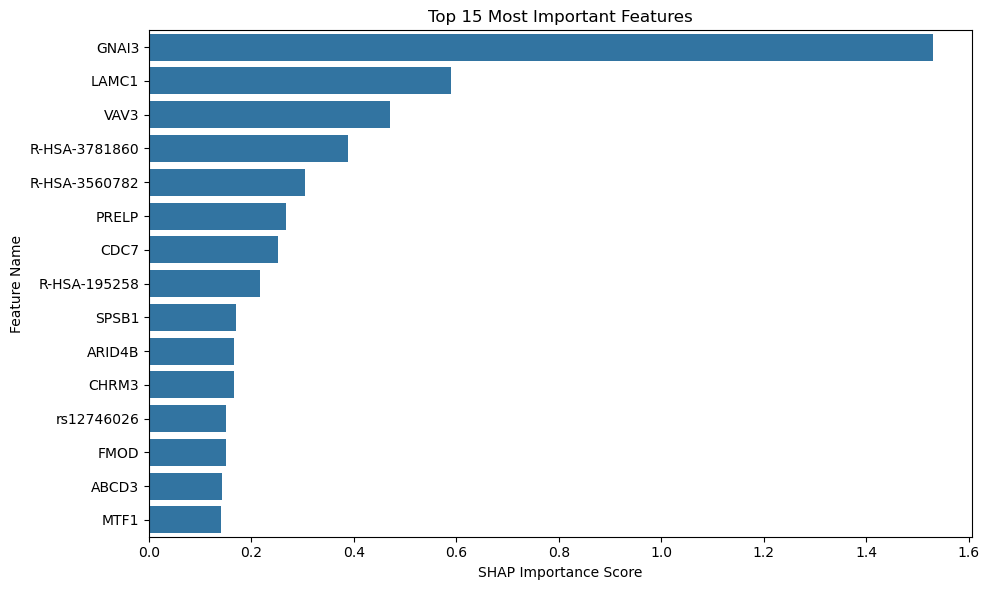

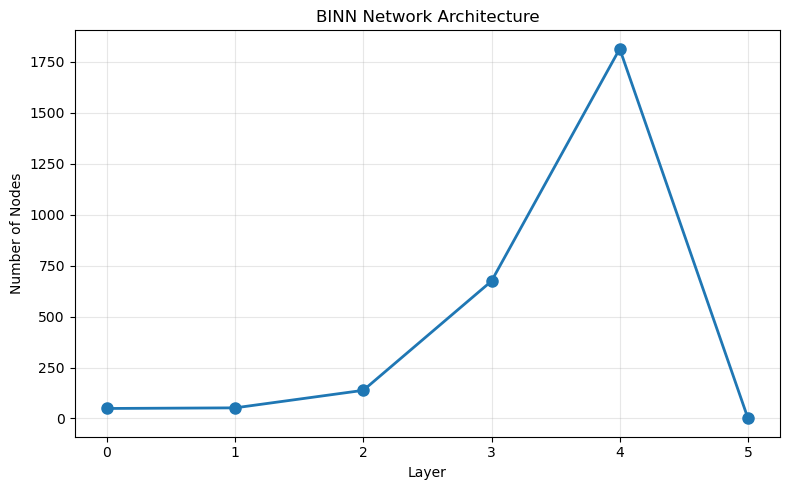

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot top important features
if len(explanations) > 0:
    top_features = (
        explanations
        .groupby('source_node')['importance']
        .sum()
        .sort_values(ascending=False)
        .head(15)
    )
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_features.values, y=top_features.index)
    plt.title('Top 15 Most Important Features')
    plt.xlabel('SHAP Importance Score')
    plt.ylabel('Feature Name')
    plt.tight_layout()
    plt.show()

# Plot network layer sizes
layer_sizes = [matrix.shape[0] for matrix in results['binn'].connectivity_matrices]
layer_sizes.append(results['binn'].connectivity_matrices[-1].shape[1])

plt.figure(figsize=(8, 5))
plt.plot(range(len(layer_sizes)), layer_sizes, 'o-', linewidth=2, markersize=8)
plt.title('BINN Network Architecture')
plt.xlabel('Layer')
plt.ylabel('Number of Nodes')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

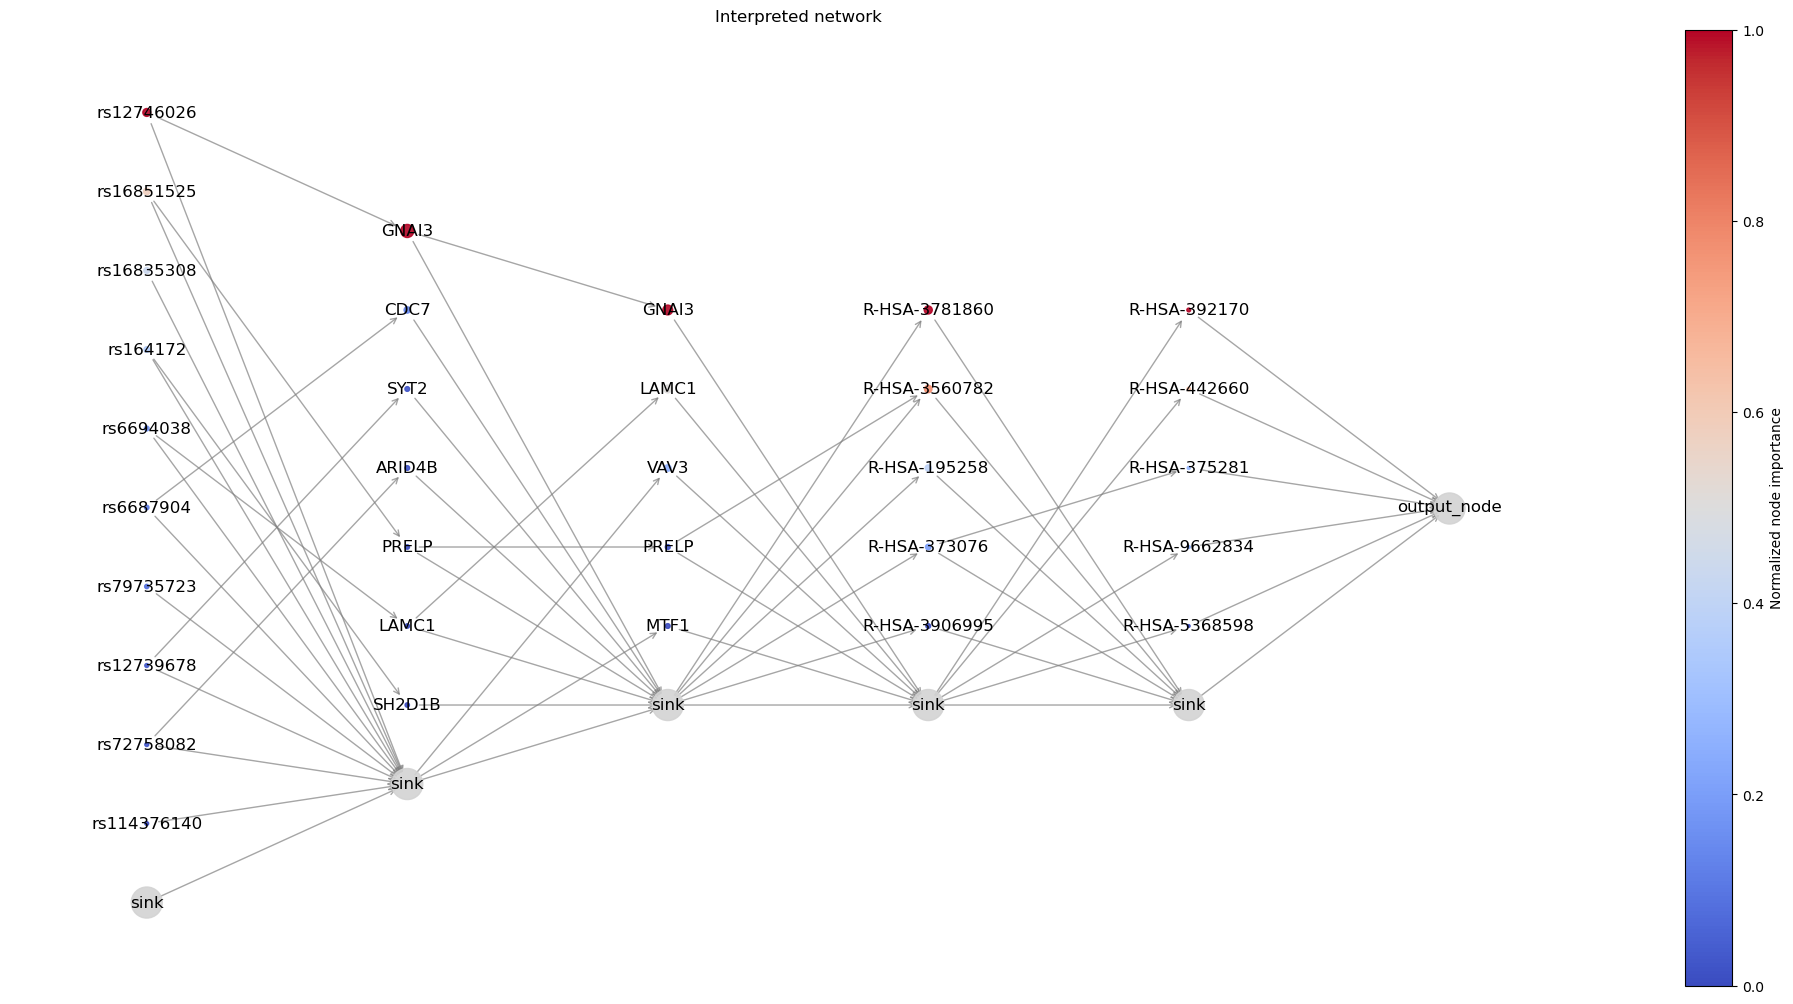

In [93]:
# @title ## 5. Plot
from binn.plot.network import visualize_binn

layer_specific_top_n = {"0": 10, "1": 7, "2": 5, "3": 5, "4": 5}

plt = visualize_binn(
    explanations,
    top_n=layer_specific_top_n,
    plot_size=(20, 10),
    sink_node_size=500,
    node_size_scaling=200,
    edge_width=1,
    node_cmap="coolwarm"
)

plt.title("Interpreted network")
plt.show()
     